## **Customer Churn Analysis**

🔹 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

🔹 2. Load Dataset

In [23]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Customer Churn.csv')  # adjust if filename differs

Saving Customer Churn.csv to Customer Churn (1).csv


🔹 3. Basic Inspection

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

🔹 4. Data Cleaning

In [27]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [28]:
df['totalcharges'] = df.groupby('contract')['totalcharges'] \
                       .transform(lambda x: x.fillna(x.median()))

🔹 5. Feature Engineering

In [29]:
labels = ['New', 'Short-term', 'Mid-term', 'Long-term']
df['tenure_group'] = pd.qcut(df['tenure'], q=4, labels=labels)

In [30]:
labels = ['Low', 'Medium', 'High', 'Very High']
df['charge_group'] = pd.qcut(df['monthlycharges'], q=4, labels=labels)

In [31]:
df['usage_intensity'] = df['monthlycharges'] / (df['tenure'] + 1)

🔹 6. Univariate Analysis

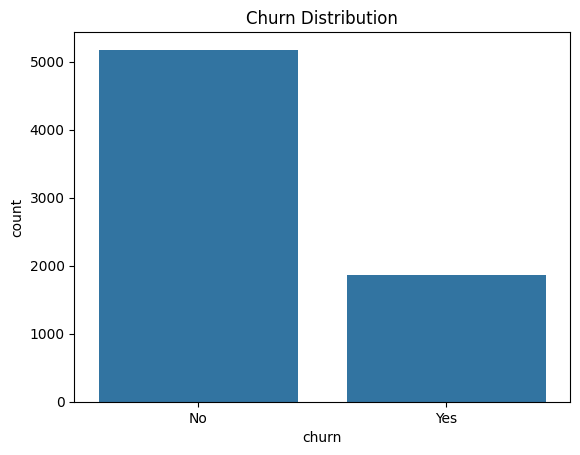

In [32]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

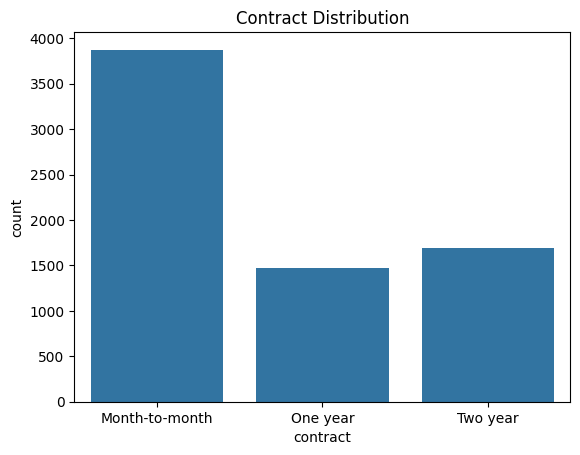

In [33]:
sns.countplot(x='contract', data=df)
plt.title("Contract Distribution")
plt.show()

🔹 7. Bivariate Analysis

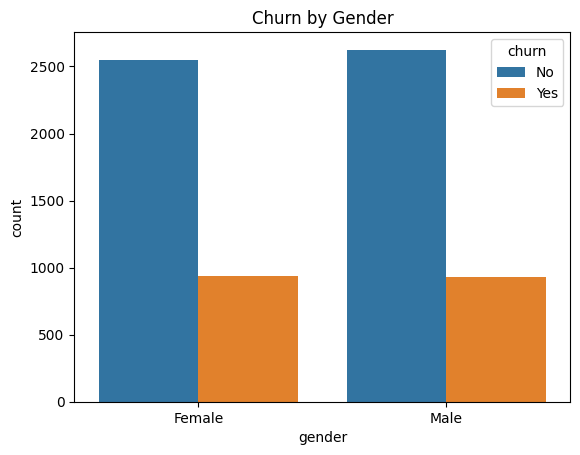

In [34]:
sns.countplot(x='gender', hue='churn', data=df)
plt.title("Churn by Gender")
plt.show()

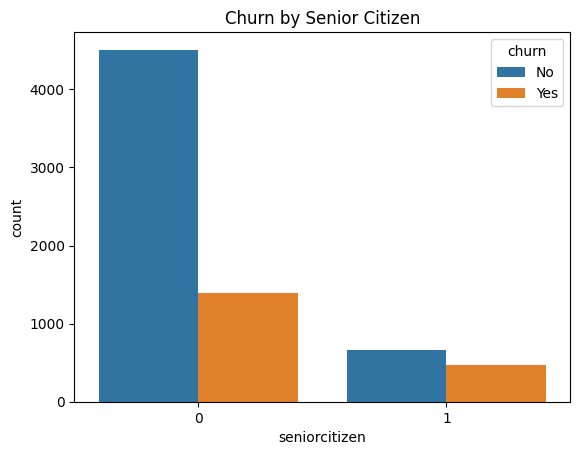

In [35]:
sns.countplot(x='seniorcitizen', hue='churn', data=df)
plt.title("Churn by Senior Citizen")
plt.show()

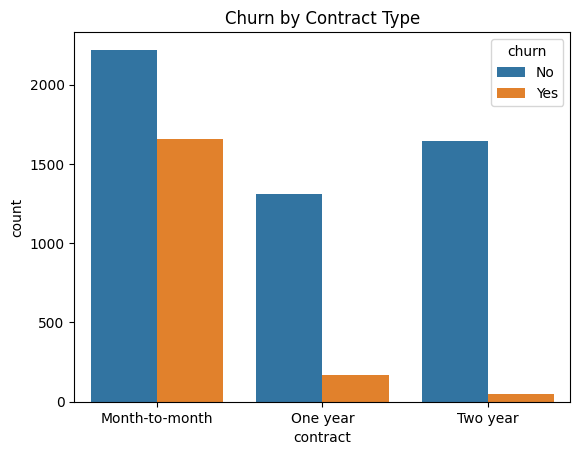

In [36]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

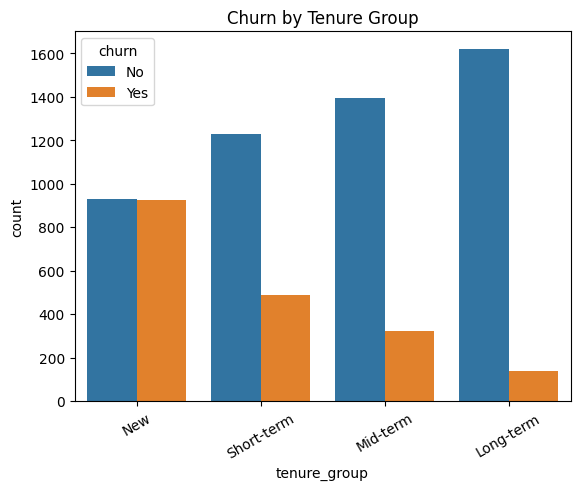

In [37]:
sns.countplot(x='tenure_group', hue='churn', data=df)
plt.xticks(rotation=30)
plt.title("Churn by Tenure Group")
plt.show()

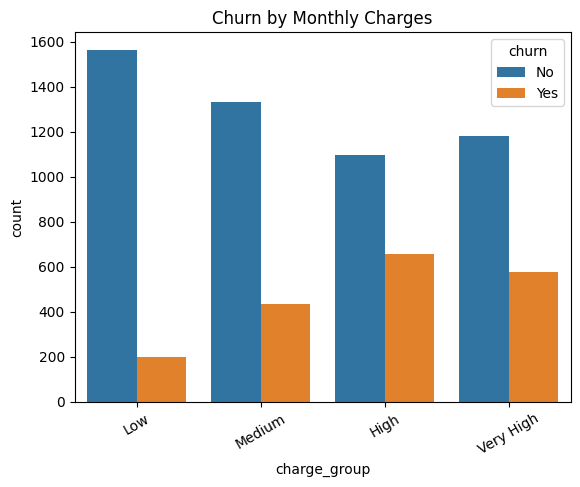

In [38]:
sns.countplot(x='charge_group', hue='churn', data=df)
plt.xticks(rotation=30)
plt.title("Churn by Monthly Charges")
plt.show()

🔹 8. Numerical Analysis

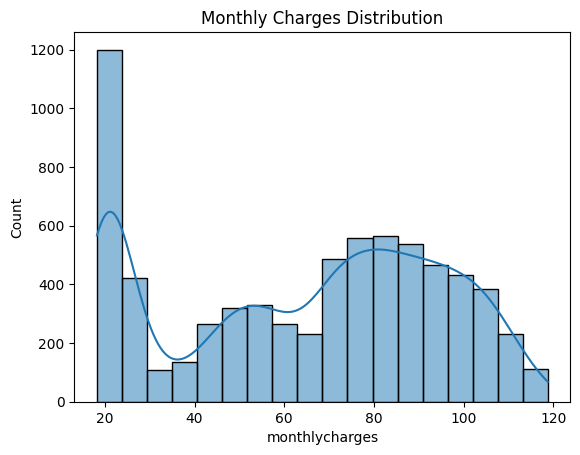

In [39]:
sns.histplot(df['monthlycharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

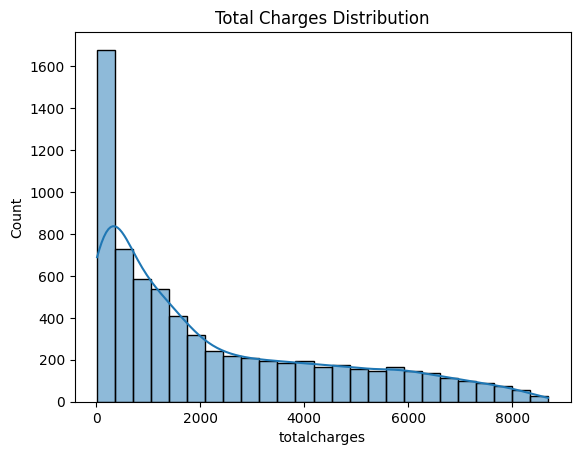

In [41]:
sns.histplot(df['totalcharges'], kde=True)
plt.title("Total Charges Distribution")
plt.show()

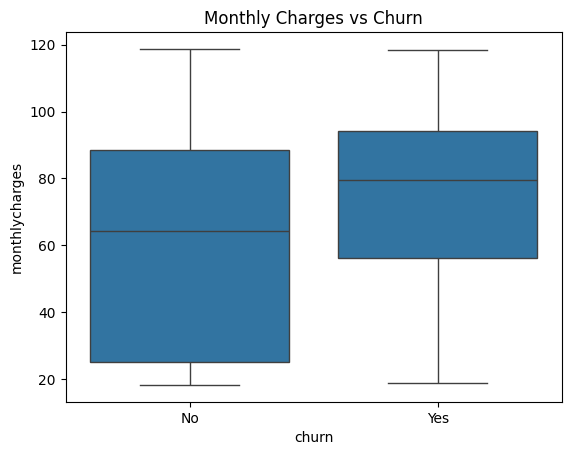

In [42]:
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

🔹 9. Correlation Analysis

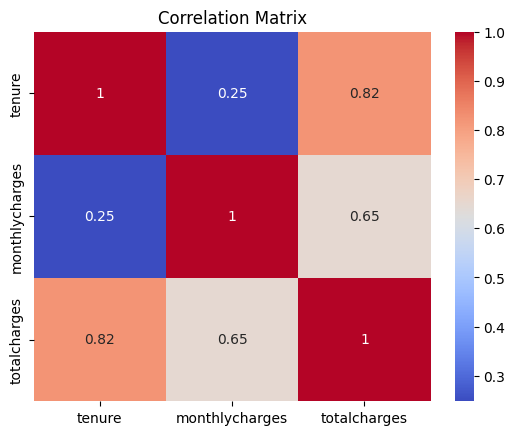

In [43]:
numeric_df = df[['tenure', 'monthlycharges', 'totalcharges']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()